In [1]:
from gpaw.new.ase_interface import GPAW
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.cm as cm
from matplotlib import colormaps
import matplotlib.colors as mcolors
import os

In [7]:
######## Functions ########

def set_directory_to_this_notebook():
    import subprocess
    from pathlib import Path

    # Get the Jupyter notebook's directory (works on any computer)
    try:
        # Ask Jupyter where the server is running
        server_info = subprocess.check_output(
            ['jupyter', 'runtime', 'list'],
            text=True, 
            stderr=subprocess.DEVNULL
        )
        # Fallback: Use current working directory from Jupyter
        notebook_dir = Path.cwd()
    except:
        # If subprocess fails, just use the current directory
        notebook_dir = Path.cwd()

    os.chdir(notebook_dir)
    print(f"Working directory set to: {os.getcwd()}")

def get_calculation_metadata(calc, e_kn):
    """
    Extract metadata about the band structure calculation.
    
    Parameters
    ----------
    calc  : GPAW calculator (new interface)
    e_kn  : (nkpts, nbands) array of eigenvalues
    
    Returns
    -------
    projector_l : list of lists — projector_l[a][p] is the l-quantum number
                  of projector p on atom a
    meta        : dict with atom/band bookkeeping info
    """
    atoms   = calc.get_atoms()
    natoms  = len(atoms)
    symbols = atoms.get_chemical_symbols()
    nkpts, nbands = e_kn.shape
    l_map_inv = {0: 's', 1: 'p', 2: 'd', 3: 'f'}
    
    # --- Extract projector l-values from the setups ---
    setups = calc.dft.setups
    projector_l = []
    nprojs_per_atom = []
    for a in range(natoms):
        ls = [phit.l for phit in setups[a].pt_j]
        projector_l.append(ls)
        nprojs_per_atom.append(len(ls))
    
    # --- Print atom projectors ---
    print("Atom projectors:")
    for a in range(natoms):
        channels = [l_map_inv[l] for l in projector_l[a]]
        print(f"  Atom {a:2d} ({symbols[a]}): {channels} "
              f"-> {nprojs_per_atom[a]} projectors")
    
    meta = {
        'e_fermi'   : calc.get_fermi_level(),
        'symbols'   : symbols,
        'natoms'    : natoms,
        'nbands'    : nbands,
        'nkpts'     : nkpts,
        'l_map_inv' : l_map_inv,
        'mn_indices': [i for i, s in enumerate(symbols) if s == 'Mn'],
        'i_indices' : [i for i, s in enumerate(symbols) if s == 'I'],
    }
    
    return projector_l, meta

def weight_by_atom_group(weights, atom_indices):
    """Sum weights over a group of atoms and all their projectors."""
    return weights[:, :, atom_indices, :].sum(axis=(2, 3))  # shape (nkpts, nbands)
 
def weight_by_l(weights, projector_l, atom_indices, l_target):
    """Sum weights over a group of atoms for a specific l channel."""
    w = np.zeros(weights.shape[:2])  # shape (nkpts, nbands)
    for a in atom_indices:
        for proj_idx, l in enumerate(projector_l[a]):
            if l == l_target:
                w += weights[:, :, a, proj_idx]
    return w  # shape (nkpts, nbands)

def plot_colored_segments(ax, x_axis, y, w, cmap_name, vmin=0, vmax=1):
    cmap = colormaps[cmap_name]
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    for i in range(len(x_axis) - 1):
        w_mid = 0.5 * (w[i] + w[i + 1])
        ax.plot([x_axis[i], x_axis[i + 1]], [y[i], y[i + 1]],
                color=cmap(norm(w_mid)), lw=2)
    return cm.ScalarMappable(norm=norm, cmap=cmap)

def plot_projection(axes_list, panel_labels, eigs, weight_list,
                    band_indices, cmap_list, ylim=(-2.5, -0.5)):
    """
    axes_list   : list of matplotlib axes, one per projection
    panel_labels: list of strings, one per projection
    weight_list : list of (nkpts, nbands) arrays, one per projection
    band_indices: list of band indices to plot

    Uses the existing x / X / labels arrays from the outer scope so that
    the k-axis matches the spin-texture plot exactly.
    """
    for ax, label, w_all, cmap_name in zip(axes_list, panel_labels,
                                            weight_list, cmap_list):
        vmax = w_all[:, band_indices].max()
        sm = None
        for b in band_indices:
            sm = plot_colored_segments(ax, k_points, eigs[:, b], w_all[:, b],
                                        cmap_name, vmin=0, vmax=vmax)
        plt.colorbar(sm, ax=ax, label='weight')
        ax.set_title(label)
        for xline in k_points_X:
            ax.axvline(x=xline, color='black', linewidth=0.8, linestyle='--')
        ax.set_xticks(k_points_X)
        ax.set_xticklabels(labels)
        ax.set_xlim(k_points[0], k_points[-1])
        ax.set_xlabel(r'$k$')
        ax.set_ylim(ylim)

In [14]:
# set directory and find data 

set_directory_to_this_notebook() # set directory to the location of this notebook

name = 'Mn3I6' + 'mode_all'
run = 0
npoints = 40

folder_name = f'{name}_bandstructure_npoint_{npoints}_run_{run}'
if not os.path.exists(folder_name):
    print(f"Folder '{folder_name}' does not exist. Please run the band structure calculation first.")
else:
    os.chdir(folder_name)
    print(f"Changed directory to: {os.getcwd()}")

Working directory set to: /Users/mgz653/Documents/Coding projects/DFT kursus/DFT-project-2026/Mn3I6mode_all_bandstructure_npoint_40_run_0
Folder 'Mn3I6mode_all_bandstructure_npoint_40_run_0' does not exist. Please run the band structure calculation first.


In [15]:
# Importing the GPAW calculation to extract metadata for plotting
cal_band = GPAW(f'{name}_band_point{npoints}.gpw', txt=None)
atoms    = cal_band.get_atoms()
name     = atoms.get_chemical_formula(mode='metal') #saving name as a string for naming text files later.

/Users/mgz653/Documents/Coding projects/new_venv/lib/python3.9/site-packages/gpaw/setup.py:1059: RuntimeWarning: divide by zero encountered in matmul
  N0_p = N0_q @ T_Lqp[0] * sqrt(4 * pi)
/Users/mgz653/Documents/Coding projects/new_venv/lib/python3.9/site-packages/gpaw/setup.py:1059: RuntimeWarning: overflow encountered in matmul
  N0_p = N0_q @ T_Lqp[0] * sqrt(4 * pi)
/Users/mgz653/Documents/Coding projects/new_venv/lib/python3.9/site-packages/gpaw/setup.py:1059: RuntimeWarning: invalid value encountered in matmul
  N0_p = N0_q @ T_Lqp[0] * sqrt(4 * pi)


In [16]:
# Importing Energies, k-points, labels, spin texture and weights for plotting

e_kn        = np.load(name + f'_band_npoint{npoints}_energies.npy')
k_points    = np.load(name + f'_band_npoint{npoints}_x.npy')
k_points_X  = np.load(name + f'_band_npoint{npoints}_BigX.npy')
labels      = [r'$-\bar{M}$', r'$\Gamma$', r'$\bar{M}$']
s_kn        = np.load(name + f'_band_npoint{npoints}_spintexture.npy')
weights     = np.load(name + f'_band_npoint{npoints}_orbital_and_atomic_weights.npy')


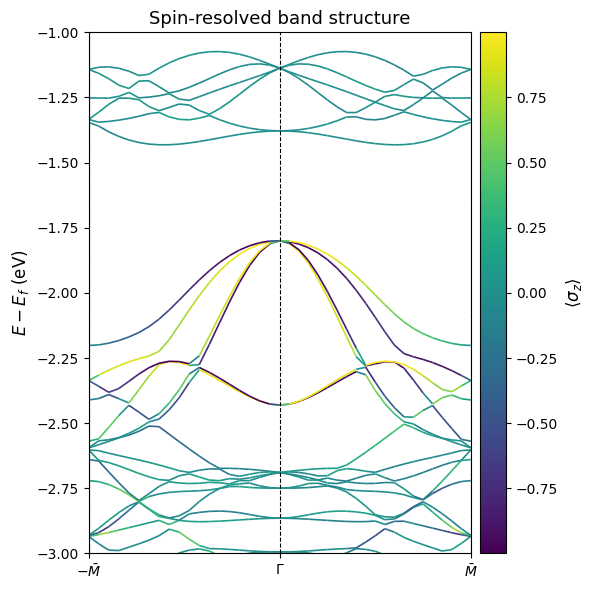

In [20]:
# Plotting the spin-resolved band structure

fig, ax = plt.subplots(figsize=(6, 6))

cmap = plt.cm.viridis
# vmin, vmax = -1, 1
vmin, vmax = np.min(s_kn) , np.max(s_kn)

for n in range(e_kn.shape[1]):
    points   = np.array([k_points, e_kn[:, n]]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    colors   = (s_kn[:-1, n] + s_kn[1:, n]) / 2

    lc = LineCollection(segments, cmap=cmap, norm=plt.Normalize(vmin, vmax))
    lc.set_array(colors)
    lc.set_linewidth(1.2)
    ax.add_collection(lc)

cbar = plt.colorbar(lc, ax=ax, pad=0.02)
cbar.set_label(r'$\langle \sigma_z \rangle$', fontsize=12)

for xline in k_points_X:
    ax.axvline(x=xline, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(k_points_X)
ax.set_xticklabels(labels)

ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')
ax.set_xlim(k_points[0], k_points[-1])
ax.set_ylim(-3, -1)
ax.set_ylabel(r'$E - E_f$ (eV)', fontsize=12)
ax.set_title('Spin-resolved band structure', fontsize=13)

plt.tight_layout()
plt.savefig(name+'_spin_bands.png', dpi=150)
plt.savefig(name+'_spin_bands.pdf')

# print("Done. Results saved to", name + f'_band_npoint{npoints}')

In [18]:
print("Calculating orbital decomposition")
 
# --- Extract metadata and projector info ---
projector_l, meta = get_calculation_metadata(cal_band, e_kn)
 
mn_idx = meta['mn_indices']
i_idx  = meta['i_indices']

# Atomic decomposition — shape (nkpts, nbands)
w_mn = weight_by_atom_group(weights, mn_idx)
w_i  = weight_by_atom_group(weights, i_idx)
 
# Orbital decomposition on Mn — shape (nkpts, nbands)
w_mn_s = weight_by_l(weights, projector_l, mn_idx, l_target=0)
w_mn_p = weight_by_l(weights, projector_l, mn_idx, l_target=1)
w_mn_d = weight_by_l(weights, projector_l, mn_idx, l_target=2)
 
# Orbital decomposition on I — shape (nkpts, nbands)
w_i_s  = weight_by_l(weights, projector_l, i_idx, l_target=0)
w_i_p  = weight_by_l(weights, projector_l, i_idx, l_target=1)
w_i_d  = weight_by_l(weights, projector_l, i_idx, l_target=2)

Calculating orbital decomposition
Atom projectors:
  Atom  0 (Mn): ['s', 's', 'p', 'p', 'd', 'd'] -> 6 projectors
  Atom  1 (I): ['s', 'p', 's', 'p', 'd'] -> 5 projectors
  Atom  2 (I): ['s', 'p', 's', 'p', 'd'] -> 5 projectors
  Atom  3 (Mn): ['s', 's', 'p', 'p', 'd', 'd'] -> 6 projectors
  Atom  4 (I): ['s', 'p', 's', 'p', 'd'] -> 5 projectors
  Atom  5 (I): ['s', 'p', 's', 'p', 'd'] -> 5 projectors
  Atom  6 (Mn): ['s', 's', 'p', 'p', 'd', 'd'] -> 6 projectors
  Atom  7 (I): ['s', 'p', 's', 'p', 'd'] -> 5 projectors
  Atom  8 (I): ['s', 'p', 's', 'p', 'd'] -> 5 projectors


Orbital decomposition done.


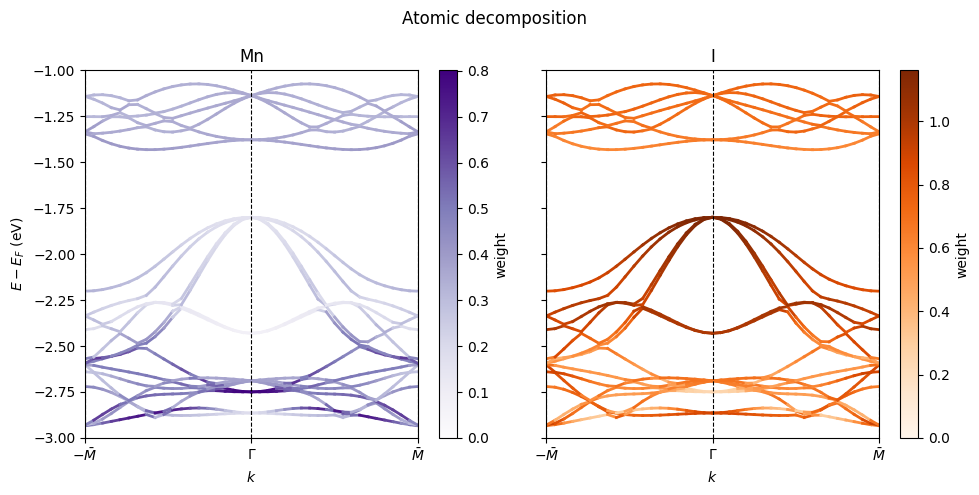

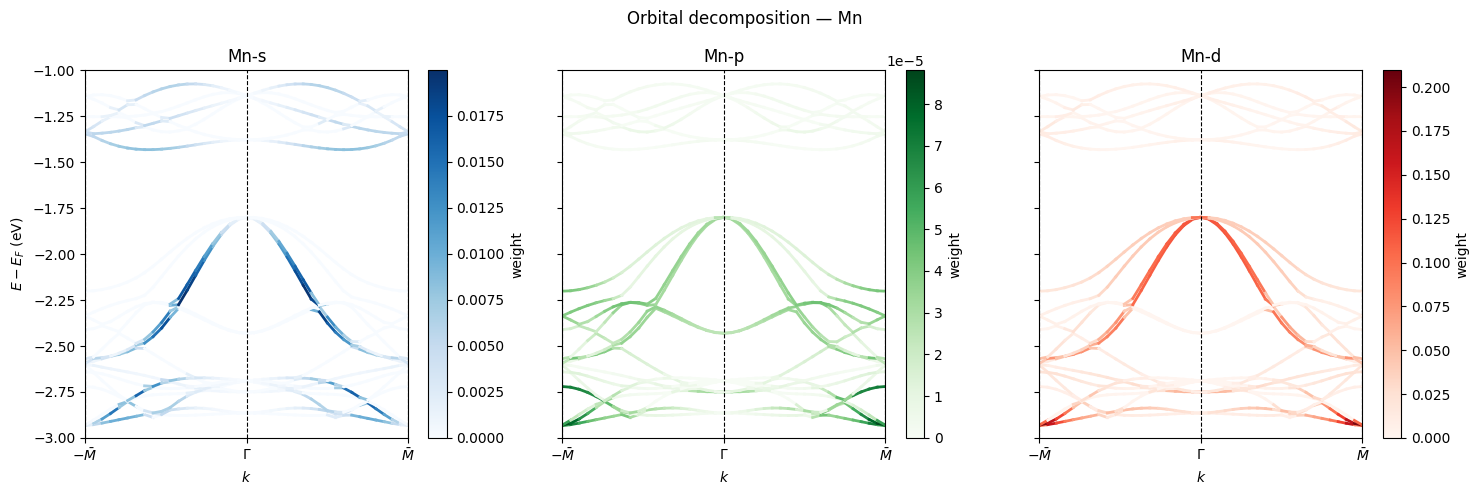

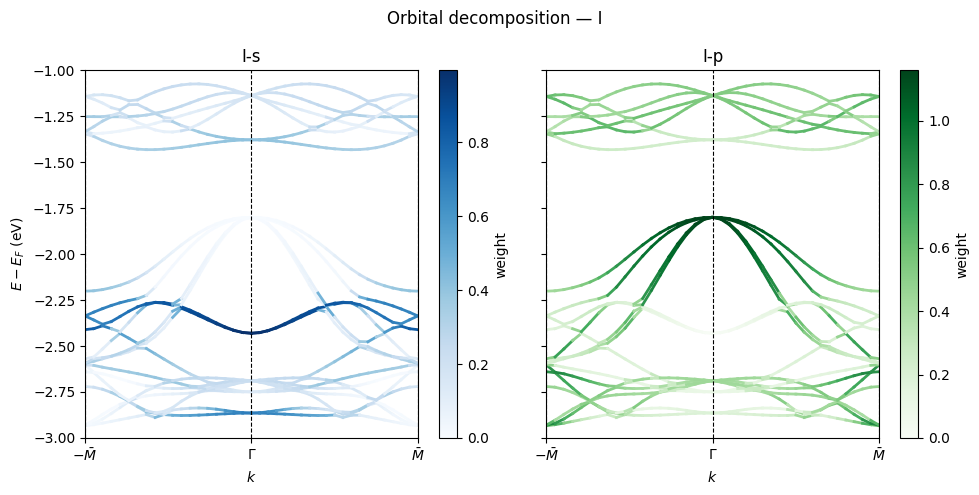

In [21]:
# Plotting the decompositions 

band_indices = list(range(67, 87))  # adjust to bands of interest
y_max, ymin = -1,-3


# --- Atomic decomposition plot ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
axes[0].set_ylabel(r'$E - E_F$ (eV)')
plot_projection(axes, ['Mn', 'I'], e_kn,
                [w_mn, w_i], band_indices, ['Purples', 'Oranges'],ylim=(ymin, y_max))
fig.suptitle('Atomic decomposition')
plt.tight_layout()
plt.savefig(name+'_Atomic_decomp.png', dpi=150)
plt.savefig(name+'_Atomic_decomp.pdf', bbox_inches='tight')

# --- Orbital decomposition on Mn ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
axes[0].set_ylabel(r'$E - E_F$ (eV)')
plot_projection(axes, ['Mn-s', 'Mn-p', 'Mn-d'], e_kn,
                [w_mn_s, w_mn_p, w_mn_d], band_indices,
                ['Blues', 'Greens', 'Reds'],ylim=(ymin, y_max))
fig.suptitle('Orbital decomposition — Mn')
plt.tight_layout()
plt.savefig(name+'_Orbital_decomp_Mn.png', dpi=150)
plt.savefig(name+'_Orbital_decomp_Mn.pdf', bbox_inches='tight')

# --- Orbital decomposition on I ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
axes[0].set_ylabel(r'$E - E_F$ (eV)')
plot_projection(axes, ['I-s', 'I-p'], e_kn,
                [w_i_s, w_i_p], band_indices,
                ['Blues', 'Greens'],ylim=(ymin, y_max))
fig.suptitle('Orbital decomposition — I')
plt.tight_layout()
plt.savefig(name+'_Orbital_decomp_I.png', dpi=150)
plt.savefig(name+'_Orbital_decomp_I.pdf', bbox_inches='tight')

print("Orbital decomposition done.")